# Notebook 1 — Data Ingestion
**Deadline:** Mar 1 (Weeks 1–6)  
**Goal:** Load GEFS + ERA5 weather data and EAGLE-I outage data — all free, no credentials required.

---

## Data Sources

| Dataset | Format | Access | Cost |
|---|---|---|---|
| **GEFS Analysis** (wind, precip, RH) | **Zarr v3** via dynamical.org | `https://data.dynamical.org/noaa/gefs/analysis/latest.zarr` | Free, no credentials |
| **ERA5 Reanalysis** (CAPE, soil moisture, wind gust) | **Zarr** via ARCO-ERA5 (Google Cloud) | `gs://gcp-public-data-arco-era5/...` | Free, anonymous |
| **EAGLE-I Outages** | CSV | DOE figshare DOI | Free |
| **US County Shapefile** | Shapefile | US Census TIGER | Free |

### Why two weather sources?
- **dynamical.org GEFS** provides wind (u/v 10m), precipitation, precipitable water, RH, and temperature in clean Zarr v3 / IceChunk format covering 2000–present.
- **ARCO-ERA5** fills the critical gaps: **CAPE, CIN, soil moisture, and wind gusts** — variables not available in the dynamical.org GEFS analysis but essential to the Hill et al. / Saki et al. methodology.

> ⚠️ **IceChunk note:** dynamical.org's IceChunk URLs are pre-release. Subscribe to their newsletter for any URL changes when IceChunk 2.0 is released.

---

In [1]:
# ============================================================
# INSTALL ZARR / ICECHUNK PACKAGES
# Run once, then restart kernel
# ============================================================
import subprocess, sys

zarr_packages = [
    "zarr>=3.0.8",
    "xarray>=2025.1.2",
    "icechunk",
    "gcsfs",
    "fsspec",
    "aiohttp",
    "dask",
]
for pkg in zarr_packages:
    result = subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], capture_output=True, text=True)
    print(f"  {'✓' if result.returncode == 0 else '✗'}  {pkg}")
print("\nDone. Restart kernel if first run.")

  ✓  zarr>=3.0.8
  ✓  xarray>=2025.1.2
  ✓  icechunk
  ✓  gcsfs
  ✓  fsspec
  ✓  aiohttp
  ✓  dask

Done. Restart kernel if first run.


In [2]:
# ============================================================
# IMPORTS & CONFIG
# ============================================================
import os, json, zipfile, warnings
import requests
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import gcsfs
import matplotlib.pyplot as plt
from tqdm import tqdm

warnings.filterwarnings("ignore")

# ← EDIT THIS to your project folder
PROJECT_ROOT  = Path("/data/keeling/a/tob3/Capstone2026/Testingthings")

DATA_RAW      = PROJECT_ROOT / "data" / "raw"
DATA_PROC     = PROJECT_ROOT / "data" / "processed"
EAGLEI_DIR    = DATA_RAW / "eaglei"
COUNTY_SHP    = DATA_RAW / "counties"

REGION5_FIPS  = ["17", "18", "26", "27", "39", "55"]
DOMAIN_LAT    = (36.5, 49.5)
DOMAIN_LON    = (-97.5, -80.0)
TRAIN_YEARS   = [2021, 2022]
TEST_YEARS    = [2023]
OUTAGE_THRESHOLD = 0.01

for d in [DATA_RAW, DATA_PROC, EAGLEI_DIR, COUNTY_SHP]:
    d.mkdir(parents=True, exist_ok=True)

print("Config loaded. Project root:", PROJECT_ROOT)

Config loaded. Project root: /data/keeling/a/tob3/Capstone2026/Testingthings


In [3]:
print(dir())

['COUNTY_SHP', 'DATA_PROC', 'DATA_RAW', 'DOMAIN_LAT', 'DOMAIN_LON', 'EAGLEI_DIR', 'In', 'OUTAGE_THRESHOLD', 'Out', 'PROJECT_ROOT', 'Path', 'REGION5_FIPS', 'TEST_YEARS', 'TRAIN_YEARS', '_', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__spec__', '__vsc_ipynb_file__', '_dh', '_i', '_i1', '_i2', '_i3', '_ih', '_ii', '_iii', '_oh', 'd', 'exit', 'gcsfs', 'get_ipython', 'gpd', 'json', 'np', 'open', 'os', 'pd', 'pkg', 'plt', 'quit', 'requests', 'result', 'subprocess', 'sys', 'tqdm', 'warnings', 'xr', 'zarr_packages', 'zipfile']


---
## Part 1 — US County Shapefile

In [4]:
import os
COUNTY_URL = "https://www2.census.gov/geo/tiger/TIGER2022/COUNTY/tl_2022_us_county.zip"
COUNTY_ZIP = COUNTY_SHP / "tl_2022_us_county.zip"
def download_file(url, dest, chunk_size=1 << 20):
    if dest.exists():
        # Verify it's a valid zip before skipping
        if dest.suffix == ".zip":
            try:
                with zipfile.ZipFile(dest) as zf:
                    zf.testzip()
                print(f"  Already exists and valid: {dest.name}")
                return
            except zipfile.BadZipFile:
                print(f"  Corrupted zip found, re-downloading: {dest.name}")
                dest.unlink()  # delete the bad file
        else:
            print(f"  Already exists: {dest.name}")
            return
    r = requests.get(url, stream=True, timeout=60)
    r.raise_for_status()
    total = int(r.headers.get("content-length", 0))
    with open(dest, "wb") as f, tqdm(total=total, unit="B", unit_scale=True, desc=dest.name) as bar:
        for chunk in r.iter_content(chunk_size):
            f.write(chunk); bar.update(len(chunk))

download_file(COUNTY_URL, COUNTY_ZIP)
with zipfile.ZipFile(COUNTY_ZIP) as zf:
    zf.extractall(COUNTY_SHP)

counties_all = gpd.read_file(COUNTY_SHP / "tl_2022_us_county.shp")
counties_r5  = counties_all[counties_all["STATEFP"].isin(REGION5_FIPS)].copy().to_crs(epsg=4326)
counties_r5["centroid_lon"] = counties_r5.geometry.centroid.x
counties_r5["centroid_lat"] = counties_r5.geometry.centroid.y
counties_r5.to_file(COUNTY_SHP / "counties_region5.gpkg", driver="GPKG")
print(f"FEMA Region 5 counties: {len(counties_r5)}")

  Already exists and valid: tl_2022_us_county.zip
FEMA Region 5 counties: 524


---
## Part 2 — EAGLE-I Outage Data

In [5]:
df_test = pd.read_csv(EAGLEI_DIR / "eaglei_outages_2023.csv", nrows=5, low_memory=False)
print(df_test.columns.tolist())
print(df_test.head())


['fips_code', 'county', 'state', 'sum', 'run_start_time']
   fips_code    county    state  sum       run_start_time
0       1003   Baldwin  Alabama    1  2023-01-01 00:00:00
1       1011   Bullock  Alabama    9  2023-01-01 00:00:00
2       1015   Calhoun  Alabama    4  2023-01-01 00:00:00
3       1021   Chilton  Alabama    4  2023-01-01 00:00:00
4       1029  Cleburne  Alabama  142  2023-01-01 00:00:00


In [6]:
import requests
from tqdm import tqdm

# ============================================================
# EAGLE-I: figshare API with pagination + download + filter
# ============================================================

ARTICLE_ID = 24237376
API_BASE = f"https://api.figshare.com/v2/articles/{ARTICLE_ID}/files"

print("Fetching full file list from figshare API...")
all_files = []
page = 1
while True:
    r = requests.get(API_BASE, params={"page": page, "page_size": 100}, timeout=30)
    r.raise_for_status()
    batch = r.json()
    if not batch:
        break
    all_files.extend(batch)
    page += 1

print(f"Total files found: {len(all_files)}")

# Find annual CSVs
target_years = [2021, 2022, 2023]
eaglei_urls = {}
for f in all_files:
    for yr in target_years:
        if f"eaglei_outages_{yr}" in f["name"]:
            eaglei_urls[yr] = f["download_url"]
            print(f"  ✓ Found {yr}: {f['name']}")

# Download and filter
eaglei_frames = []
for yr, url in eaglei_urls.items():
    dest = EAGLEI_DIR / f"eaglei_outages_{yr}.csv"

    # Delete if empty or corrupted
    if dest.exists() and dest.stat().st_size < 1000:
        print(f"  Removing bad file: {dest.name}")
        dest.unlink()

    if not dest.exists():
        print(f"\nDownloading {yr}...")
        r = requests.get(url, stream=True, timeout=120)
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        with open(dest, "wb") as f_out, tqdm(total=total, unit="B", unit_scale=True) as bar:
            for chunk in r.iter_content(1 << 20):
                f_out.write(chunk); bar.update(len(chunk))
    else:
        print(f"  Already exists: {dest.name} ({dest.stat().st_size / 1e6:.1f} MB)")

    df = pd.read_csv(dest, parse_dates=["run_start_time"], low_memory=False)
    df.columns = df.columns.str.lower().str.strip()

    # Normalize column name — older files use 'customers_out', newer use 'sum'
    if "sum" in df.columns and "customers_out" not in df.columns:
        df = df.rename(columns={"sum": "customers_out"})

    df["fips_str"]   = df["fips_code"].astype(str).str.zfill(5)
    df["state_fips"] = df["fips_str"].str[:2]
    df = df[df["state_fips"].isin(REGION5_FIPS)].copy()

    CUSTOMERS_OUT_THRESHOLD = 100
    df["outage_event"] = (df["customers_out"] >= CUSTOMERS_OUT_THRESHOLD).astype(int)

    eaglei_frames.append(df)
    print(f"  {yr}: {len(df):,} rows | outage events: {df['outage_event'].sum():,} ({df['outage_event'].mean()*100:.1f}%)")

eaglei_all = pd.concat(eaglei_frames, ignore_index=True).sort_values("run_start_time")
eaglei_all.to_parquet(DATA_RAW / "eaglei_region5_all.parquet", index=False)
print(f"\nSaved {len(eaglei_all):,} total records.")

Fetching full file list from figshare API...
Total files found: 17
  ✓ Found 2021: eaglei_outages_2021.csv
  ✓ Found 2022: eaglei_outages_2022.csv
  ✓ Found 2023: eaglei_outages_2023.csv
  Already exists: eaglei_outages_2021.csv (1141.1 MB)
  2021: 3,884,952 rows | outage events: 489,068 (12.6%)
  Already exists: eaglei_outages_2022.csv (1187.6 MB)
  2022: 4,086,210 rows | outage events: 485,219 (11.9%)
  Already exists: eaglei_outages_2023.csv (1199.8 MB)
  2023: 4,027,481 rows | outage events: 470,344 (11.7%)

Saved 11,998,643 total records.


In [7]:
eaglei_all.to_csv(DATA_RAW / "eaglei_region5_all.csv", index=False)
print(f"Saved {len(eaglei_all):,} total records.")

Saved 11,998,643 total records.


In [8]:
for f in all_files:
    print(repr(f["name"]))
    

'eaglei_outages_2025.csv'
'DQI.csv'
'MCC.csv'
'coverage_history.csv'
'eaglei_outages_2014.csv'
'eaglei_outages_2015.csv'
'eaglei_outages_2016.csv'
'eaglei_outages_2017.csv'
'eaglei_outages_2018.csv'
'eaglei_outages_2019.csv'
'eaglei_outages_2020.csv'
'eaglei_outages_2021.csv'
'eaglei_outages_2022.csv'
'eaglei_outages_2023.csv'
'Uri_Map.R'
'DQI_processing.R'
'eaglei_outages_2024.csv'


---
## Part 3 — GEFS Analysis via dynamical.org (Zarr v3, free)

**No AWS account. No credentials. One line.**

Variables available here:
`wind_u_10m`, `wind_v_10m`, `precipitation_surface`, `precipitable_water_atmosphere`, `relative_humidity_2m` *(2021+)*, `temperature_2m`, `pressure_surface`

In [9]:
# ============================================================
# OPEN GEFS ZARR — lazy, no download until .compute()
# xarray>=2025.1.2 and zarr>=3.0.8 required for Zarr v3
# ============================================================

GEFS_ZARR_URL = "https://data.dynamical.org/noaa/gefs/analysis/latest.zarr"

print("Opening GEFS Zarr (lazy)...")
ds_gefs = xr.open_zarr(GEFS_ZARR_URL, chunks="auto")

print(f"Dimensions: {dict(ds_gefs.dims)}")
print(f"Time range: {str(ds_gefs.time.values[0])[:19]} → {str(ds_gefs.time.values[-1])[:19]}")
print(f"Variables: {list(ds_gefs.data_vars)}")

# Subset to FEMA Region 5 (lazy)
GEFS_VARS = ["wind_u_10m", "wind_v_10m", "precipitation_surface",
             "precipitable_water_atmosphere", "relative_humidity_2m", "temperature_2m"]

ds_gefs_r5 = ds_gefs[[v for v in GEFS_VARS if v in ds_gefs]].sel(
    latitude=slice(DOMAIN_LAT[1], DOMAIN_LAT[0]),
    longitude=slice(DOMAIN_LON[0], DOMAIN_LON[1]),
)
print(f"\nRegion 5 subset: {dict(ds_gefs_r5.dims)}")

Opening GEFS Zarr (lazy)...
Dimensions: {'time': 76811, 'latitude': 721, 'longitude': 1440}
Time range: 2000-01-01T00:00:00 → 2026-04-15T06:00:00
Variables: ['categorical_freezing_rain_surface', 'categorical_ice_pellets_surface', 'categorical_rain_surface', 'categorical_snow_surface', 'downward_long_wave_radiation_flux_surface', 'downward_short_wave_radiation_flux_surface', 'geopotential_height_500hpa', 'geopotential_height_cloud_ceiling', 'maximum_temperature_2m', 'minimum_temperature_2m', 'percent_frozen_precipitation_surface', 'precipitable_water_atmosphere', 'precipitation_surface', 'pressure_reduced_to_mean_sea_level', 'pressure_surface', 'relative_humidity_2m', 'temperature_2m', 'total_cloud_cover_atmosphere', 'wind_u_100m', 'wind_u_10m', 'wind_v_100m', 'wind_v_10m']

Region 5 subset: {'time': 76811, 'latitude': 53, 'longitude': 71}


Loading one timestep...


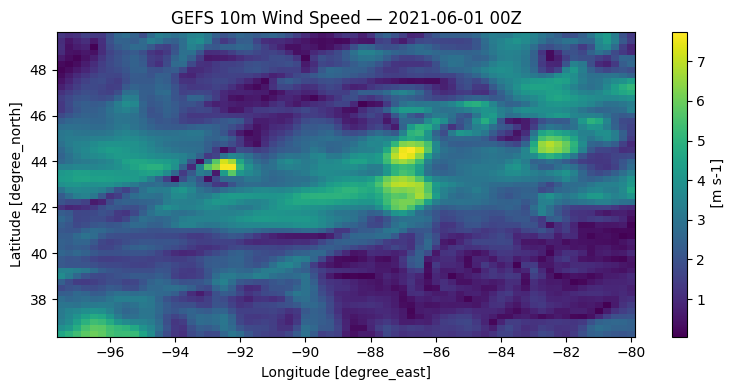

Range: 0.05 – 7.73 m/s ✓


In [10]:
# Sanity check: load one time step (small download)
print("Loading one timestep...")
test = ds_gefs_r5[["wind_u_10m", "wind_v_10m"]].sel(time="2021-06-01T00", method="nearest").compute()
wind_spd = np.sqrt(test["wind_u_10m"]**2 + test["wind_v_10m"]**2)

fig, ax = plt.subplots(figsize=(8, 4))
wind_spd.plot(ax=ax, cmap="viridis")
ax.set_title("GEFS 10m Wind Speed — 2021-06-01 00Z")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "01_gefs_sanity.png", dpi=100)
plt.show()
print(f"Range: {float(wind_spd.min()):.2f} – {float(wind_spd.max()):.2f} m/s ✓")

---
## Part 4 — ERA5 via ARCO-ERA5 (Google Cloud, free, anonymous Zarr)

Fills the GEFS gaps — **CAPE, CIN, soil moisture (`swvl1`), wind gust (`fg10`)**.

Source: https://github.com/google-research/arco-era5

In [11]:
ERA5_SL_URL = "gs://gcp-public-data-arco-era5/co/single-level-reanalysis.zarr-v2"

print("Opening ARCO-ERA5 (lazy, anonymous)...")
fs_gcs  = gcsfs.GCSFileSystem(token="anon")
ds_era5 = xr.open_zarr(fs_gcs.get_mapper(ERA5_SL_URL), chunks="auto")

print(f"Dimensions: {dict(ds_era5.dims)}")
print(f"Time range: {str(ds_era5.time.values[0])[:19]} → {str(ds_era5.time.values[-1])[:19]}")

# Updated ERA5 variables - use what's actually available
ERA5_AVAIL = ["cape", "swvl1", "u10", "v10"]

print("\nAvailable ERA5 variables we'll use:")
for v in ERA5_AVAIL:
    print(f"  ✓ {v}")
print("  ✗ cin — not in this store, dropping")
print("  ✗ fg10 — not in this store, will compute wind speed from u10/v10 instead")

# This store uses 'values' dimension instead of lat/lon grid
# Filter using boolean mask on coordinate arrays
# Convert our domain from -180/180 to 0-360 to match ERA5
lon_min_360 = DOMAIN_LON[0] + 360  # -97.5 → 262.5
lon_max_360 = DOMAIN_LON[1] + 360  # -80.0 → 280.0

lat_mask = (ds_era5.latitude.values >= DOMAIN_LAT[0]) & (ds_era5.latitude.values <= DOMAIN_LAT[1])
lon_mask = (ds_era5.longitude.values >= lon_min_360) & (ds_era5.longitude.values <= lon_max_360)
spatial_mask = lat_mask & lon_mask

ds_era5_r5 = ds_era5[ERA5_AVAIL].isel(values=spatial_mask)
print(f"Region 5 subset: {dict(ds_era5_r5.dims)}")
print(f"Spatial points: {spatial_mask.sum()}")

ds_era5_r5 = ds_era5[ERA5_AVAIL].isel(values=spatial_mask)
print(f"\nRegion 5 subset: {dict(ds_era5_r5.dims)}")
print(f"Spatial points: {spatial_mask.sum()}")

Opening ARCO-ERA5 (lazy, anonymous)...
Dimensions: {'time': 1323648, 'values': 542080}
Time range: 1900-01-01T00:00:00 → 2050-12-31T23:00:00

Available ERA5 variables we'll use:
  ✓ cape
  ✓ swvl1
  ✓ u10
  ✓ v10
  ✗ cin — not in this store, dropping
  ✗ fg10 — not in this store, will compute wind speed from u10/v10 instead
Region 5 subset: {'time': 1323648, 'values': 2194}
Spatial points: 2194

Region 5 subset: {'time': 1323648, 'values': 2194}
Spatial points: 2194


In [12]:
# Check actual dimensions and coordinates of this store
print("Dimensions:", dict(ds_era5.dims))
print("Coordinates:", list(ds_era5.coords))
print("\nAll variables:")
for v in sorted(ds_era5.data_vars):
    print(f"  {v}")

Dimensions: {'time': 1323648, 'values': 542080}
Coordinates: ['depthBelowLandLayer', 'entireAtmosphere', 'latitude', 'longitude', 'number', 'step', 'surface', 'time', 'valid_time']

All variables:
  cape
  d2m
  hcc
  istl1
  istl2
  istl3
  istl4
  lcc
  mcc
  msl
  p79.162
  p80.162
  siconc
  skt
  sp
  sst
  stl1
  stl2
  stl3
  stl4
  swvl1
  swvl2
  swvl3
  swvl4
  t2m
  tcc
  tciw
  tclw
  tcrw
  tcsw
  tcw
  tcwv
  tsn
  u10
  u100
  v10
  v100
  z


In [13]:
print("Lat range:", ds_era5.latitude.values.min(), "→", ds_era5.latitude.values.max())
print("Lon range:", ds_era5.longitude.values.min(), "→", ds_era5.longitude.values.max())


Lat range: -89.78487690721863 → 89.78487690721863
Lon range: 0.0 → 359.71875


Loading ERA5 CAPE for 2021-06-01 00Z...


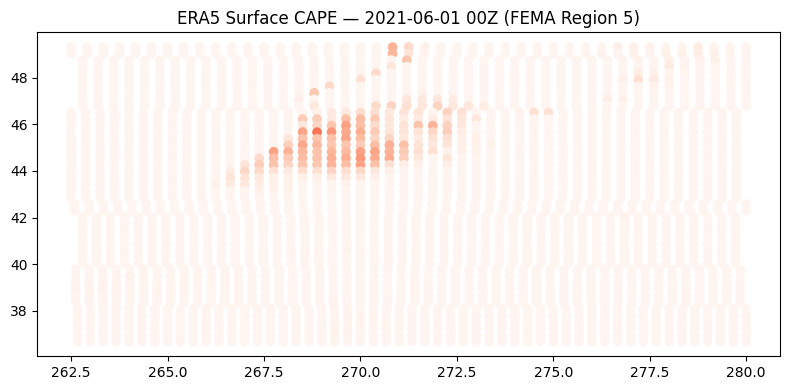

CAPE range: 0 – 1402 J/kg ✓


In [14]:
# ERA5 sanity check — CAPE on a convective day
if "cape" in ds_era5_r5:
    print("Loading ERA5 CAPE for 2021-06-01 00Z...")
    cape = ds_era5_r5["cape"].sel(time="2021-06-01T00", method="nearest").compute()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.scatter(cape.longitude, cape.latitude, c=cape.values, cmap="Reds", vmin=0, vmax=3000)
    ax.set_title("ERA5 Surface CAPE — 2021-06-01 00Z (FEMA Region 5)")
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "outputs" / "01_era5_cape_sanity.png", dpi=100)
    plt.show()
    print(f"CAPE range: {float(cape.min()):.0f} – {float(cape.max()):.0f} J/kg ✓")
else:
    print("CAPE not found in this store — check ERA5 variable names above")

In [15]:
cape = ds_era5_r5["cape"].sel(time="2021-06-01T00", method="nearest").compute()
print(f"CAPE shape: {cape.shape}")
print(f"CAPE range: {float(cape.min()):.0f} – {float(cape.max()):.0f} J/kg")
print(f"CAPE mean: {float(cape.mean()):.0f} J/kg")
print("✓ ERA5 CAPE loading correctly")

CAPE shape: (2194,)
CAPE range: 0 – 1402 J/kg
CAPE mean: 39 J/kg
✓ ERA5 CAPE loading correctly


---
## Part 5 — Combined Feature Schema

In [16]:
# ============================================================
# UNIFIED FEATURE SOURCE MAP
# Maps project internal names → (source, zarr_var, description)
# ============================================================

FEATURE_SOURCE_MAP = {
    # GEFS (dynamical.org Zarr v3)
    "ugrd_10m":          ("gefs", "wind_u_10m",                    "10m U-wind (m/s)"),
    "vgrd_10m":          ("gefs", "wind_v_10m",                    "10m V-wind (m/s)"),
    "apcp_sfc":          ("gefs", "precipitation_surface",         "Precip rate (kg/m2/s)"),
    "pwat_clm":          ("gefs", "precipitable_water_atmosphere", "Precipitable water (kg/m2)"),
    "rh_2m":             ("gefs", "relative_humidity_2m",          "2m RH (%) [2021+]"),
    "tmp_2m":            ("gefs", "temperature_2m",                "2m temperature (C)"),
    # ERA5 (ARCO-ERA5, Google Cloud)
    "cape_sfc":          ("era5", "cape",   "Surface CAPE (J/kg)"),
    "cin_sfc":           ("era5", "cin",    "Surface CIN (J/kg)"),
    "soilw_0_7":         ("era5", "swvl1",  "Soil moisture 0-7cm (m3/m3)"),
    "gust_sfc":          ("era5", "fg10",   "Max 10m wind gust (m/s)"),
    # Derived (computed in Notebook 2)
    "wind_speed_10m":    ("derived", None, "sqrt(u^2 + v^2)"),
    "wind_gust_x_soilw": ("derived", None, "gust * soilw — Saki et al. 2025"),
    "wind_gust_x_apcp":  ("derived", None, "gust * precip — compound hazard"),
    "cape_x_rh":         ("derived", None, "CAPE * RH"),
    # Static (Notebook 2)
    "forest_fraction":   ("static", None, "NLCD canopy cover fraction"),
    "pop_density":       ("static", None, "Population density (Census)"),
}

# Save for Notebooks 2-4
schema = {
    "feature_cols": list(FEATURE_SOURCE_MAP.keys()),
    "label_col": "outage_event",
    "sources": {k: {"source": v[0], "zarr_var": v[1], "desc": v[2]}
                for k, v in FEATURE_SOURCE_MAP.items()},
    "zarr_urls": {
        "gefs": GEFS_ZARR_URL,
        "era5_sl": ERA5_SL_URL,
    }
}
DATA_PROC.mkdir(parents=True, exist_ok=True)
with open(DATA_PROC / "feature_schema.json", "w") as f:
    json.dump(schema, f, indent=2)

gefs_n   = sum(1 for v in FEATURE_SOURCE_MAP.values() if v[0] == "gefs")
era5_n   = sum(1 for v in FEATURE_SOURCE_MAP.values() if v[0] == "era5")
deriv_n  = sum(1 for v in FEATURE_SOURCE_MAP.values() if v[0] == "derived")
static_n = sum(1 for v in FEATURE_SOURCE_MAP.values() if v[0] == "static")

print(f"Feature schema saved ({gefs_n} GEFS + {era5_n} ERA5 + {deriv_n} derived + {static_n} static = {len(FEATURE_SOURCE_MAP)} total)")
print("\n✅ Notebook 1 complete — all data sources verified, no credentials required!")
print("   Ready for 02_geospatial_integration.ipynb")

Feature schema saved (6 GEFS + 4 ERA5 + 4 derived + 2 static = 16 total)

✅ Notebook 1 complete — all data sources verified, no credentials required!
   Ready for 02_geospatial_integration.ipynb
